# 05 — App-Mix Dashboard

**Goal:** produce executive-friendly app-mix views from Gigamon Application Intelligence labels.

Pair this with the `Gigamon_Shadow_IT_App_Discovery` MCP tool when leadership wants a picture, not just a number.

## Setup

Authenticate with Azure CLI (`az login`) and load workspace coordinates from `.env`.

In [1]:
import os, datetime as dt
import pandas as pd
from dotenv import load_dotenv
from azure.identity import DefaultAzureCredential
from azure.monitor.query import LogsQueryClient, LogsQueryStatus

load_dotenv()
WORKSPACE_ID = os.environ['WORKSPACE_ID']
HOURS = int(os.environ.get('TIMERANGE_HOURS', '24'))
client = LogsQueryClient(DefaultAzureCredential())
TIMESPAN = dt.timedelta(hours=HOURS)

def kql(q: str) -> pd.DataFrame:
    """Run a KQL query and return the first table as a DataFrame."""
    r = client.query_workspace(WORKSPACE_ID, q, timespan=TIMESPAN)
    if r.status != LogsQueryStatus.SUCCESS:
        raise RuntimeError(r.partial_error)
    t = r.tables[0]
    return pd.DataFrame(t.rows, columns=[c for c in t.columns])

/Users/mitchellgulledge/gigamon-sentinel-notebooks/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## Pull app-mix data

In [2]:
apps = kql('''
GigamonCcfMcpDemo_CL
| summarize Flows=count(), Bytes=sum(tolong(total_bytes)) by app_family, app_name
| order by Bytes desc
''')
apps.head()

,app_family,app_name,Flows,Bytes
0,dns,ssh,30,104350038
1,remote-admin,https,31,97301757
2,dns,tls,41,86673855
3,secure-shell,rdp,28,86274087
4,web,dns,30,79503903


## Sankey: app_family → app_name → bytes

In [3]:
import plotly.graph_objects as go
fams = apps['app_family'].unique().tolist()
names = apps['app_name'].unique().tolist()
labels = fams + names
idx = {l:i for i,l in enumerate(labels)}
fig = go.Figure(data=[go.Sankey(
    node=dict(label=labels, pad=15, thickness=14, color='#742DDC'),
    link=dict(
        source=[idx[r['app_family']] for _,r in apps.iterrows()],
        target=[idx[r['app_name']] for _,r in apps.iterrows()],
        value=[int(r['Bytes']) for _,r in apps.iterrows()],
        color='rgba(255,102,0,0.45)',
    ))])
fig.update_layout(title_text='Application Mix (Bytes)', font=dict(color='white'),
                  paper_bgcolor='#100E24', plot_bgcolor='#100E24', height=600)
fig.show()

## Shadow IT bars

Use the same category taxonomy as the MCP tool.

In [4]:
shadow = kql('''
GigamonCcfMcpDemo_CL
| extend AppLabel = tolower(strcat(app_name,'|',app_family,'|',app_tags))
| extend Category = case(
    AppLabel has_any('bittorrent','transmission','utorrent','edonkey','gnutella'), 'P2P',
    AppLabel has_any('tor','i2p','psiphon','lantern'), 'Tor/I2P/Censorship',
    AppLabel has_any('nordvpn','expressvpn','protonvpn','openvpn','wireguard','consumer-vpn'), 'Consumer_VPN',
    AppLabel has_any('teamviewer','anydesk','splashtop','rustdesk','remote-access'), 'Remote_Access',
    AppLabel has_any('dropbox','wetransfer','mega.nz','personal-cloud'), 'Personal_Cloud',
    AppLabel has_any('telegram','signal-personal','whatsapp-web','consumer-messaging'), 'Messaging',
    AppLabel has_any('twitch','netflix','youtube','streaming'), 'Streaming',
    AppLabel has_any('xmrig','minexmr','crypto-miner','monero'), 'CryptoMining',
    '')
| where Category != ''
| summarize Flows=count(), Bytes=sum(tolong(total_bytes)) by Category
| order by Bytes desc
''')
shadow

,Category,Flows,Bytes
0,Remote_Access,85,173150871
1,Tor/I2P/Censorship,76,156921699
2,Personal_Cloud,77,152237640
3,Consumer_VPN,74,152052396
4,Streaming,53,104667420
5,Messaging,25,86273127
6,CryptoMining,32,61511703
7,P2P,25,56384445


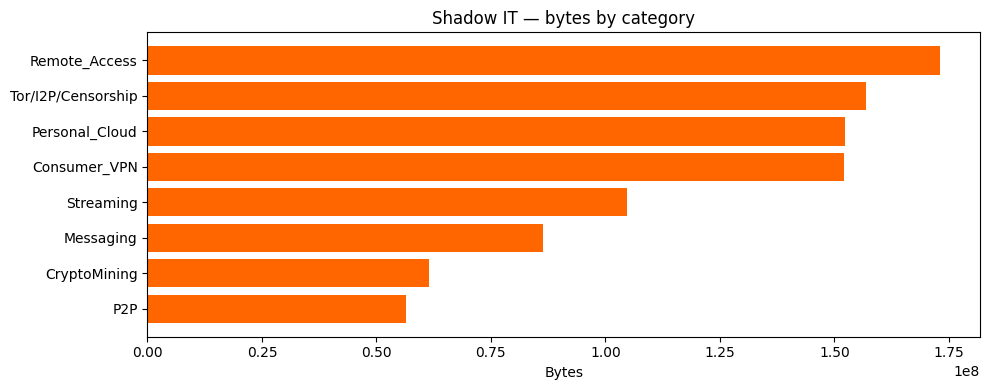

In [5]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,4))
plt.barh(shadow['Category'], shadow['Bytes'], color='#FF6600')
plt.xlabel('Bytes'); plt.title('Shadow IT — bytes by category')
plt.gca().invert_yaxis(); plt.tight_layout(); plt.show()